Goal:
Work with an imbalanced binary dataset and compare:

No resampling (baseline),

Random Oversampling,

Random Undersampling,

SMOTE (Synthetic Minority Oversampling Technique).

We’ll:

Train a Logistic Regression & Random Forest,

Evaluate with Accuracy, F1, ROC-AUC, Recall,

Visualize class distribution before/after,

Summarize trade-offs.

In [1]:
# pip install imbalanced-learn scikit-learn pandas numpy matplotlib seaborn
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, recall_score, roc_auc_score,
                             ConfusionMatrixDisplay, confusion_matrix)
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(0)

1) Create an imbalanced dataset

Class distribution: [4476  524]


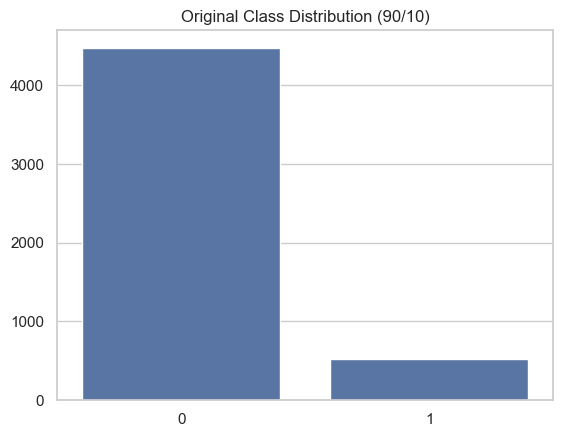

In [2]:
X, y = make_classification(
    n_samples=5000, n_features=20, n_informative=5, n_redundant=2,
    n_clusters_per_class=1, weights=[0.9, 0.1], flip_y=0.01, random_state=0
)

print("Class distribution:", np.bincount(y))
sns.barplot(x=np.unique(y), y=np.bincount(y))
plt.title("Original Class Distribution (90/10)"); plt.show()

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

2) Define helper for training & evaluation

In [3]:
def eval_model(pipe, Xtr, ytr, Xte, yte, label=""):
    pipe.fit(Xtr, ytr)
    yhat = pipe.predict(Xte)
    proba = pipe.predict_proba(Xte)[:,1] if hasattr(pipe,"predict_proba") else None
    metrics = {
        "acc": accuracy_score(yte, yhat),
        "f1": f1_score(yte, yhat),
        "recall": recall_score(yte, yhat),
        "roc_auc": roc_auc_score(yte, proba) if proba is not None else np.nan
    }
    print(f"{label:12s} | Acc={metrics['acc']:.3f}  F1={metrics['f1']:.3f}  Recall={metrics['recall']:.3f}  ROC-AUC={metrics['roc_auc']:.3f}")
    return metrics

3) Pipelines with different resampling strategies
We’ll test both Logistic Regression and Random Forest.

In [4]:
strategies = {
    "Baseline": None,
    "Oversample": RandomOverSampler(random_state=0),
    "Undersample": RandomUnderSampler(random_state=0),
    "SMOTE": SMOTE(random_state=0)
}

results = []
for name, sampler in strategies.items():
    for model, clf in [("LogReg", LogisticRegression(max_iter=2000)), 
                       ("RF", RandomForestClassifier(n_estimators=400, random_state=0, n_jobs=-1))]:
        if sampler is None:
            pipe = Pipeline([('sc', StandardScaler()), ('clf', clf)])
        else:
            pipe = ImbPipeline([('sc', StandardScaler()), ('sampler', sampler), ('clf', clf)])
        metrics = eval_model(pipe, Xtr, ytr, Xte, yte, f"{name}-{model}")
        results.append({"strategy": name, "model": model, **metrics})

Baseline-LogReg | Acc=0.954  F1=0.750  Recall=0.657  ROC-AUC=0.960
Baseline-RF  | Acc=0.963  F1=0.804  Recall=0.724  ROC-AUC=0.965
Oversample-LogReg | Acc=0.907  F1=0.667  Recall=0.886  ROC-AUC=0.957
Oversample-RF | Acc=0.967  F1=0.832  Recall=0.781  ROC-AUC=0.964
Undersample-LogReg | Acc=0.902  F1=0.652  Recall=0.876  ROC-AUC=0.959
Undersample-RF | Acc=0.936  F1=0.748  Recall=0.905  ROC-AUC=0.965
SMOTE-LogReg | Acc=0.917  F1=0.689  Recall=0.876  ROC-AUC=0.958
SMOTE-RF     | Acc=0.957  F1=0.796  Recall=0.800  ROC-AUC=0.965


4) Compare strategies

      strategy   model    acc     f1  recall  roc_auc
0     Baseline  LogReg  0.954  0.750   0.657    0.960
1     Baseline      RF  0.963  0.804   0.724    0.965
2   Oversample  LogReg  0.907  0.667   0.886    0.957
3   Oversample      RF  0.967  0.832   0.781    0.964
4  Undersample  LogReg  0.902  0.652   0.876    0.959
5  Undersample      RF  0.936  0.748   0.905    0.965
6        SMOTE  LogReg  0.917  0.689   0.876    0.958
7        SMOTE      RF  0.957  0.796   0.800    0.965


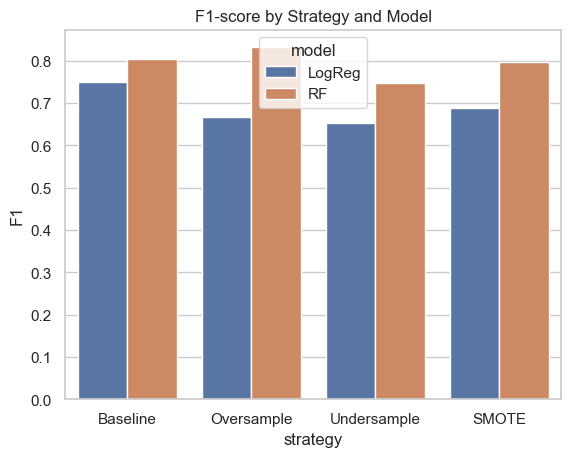

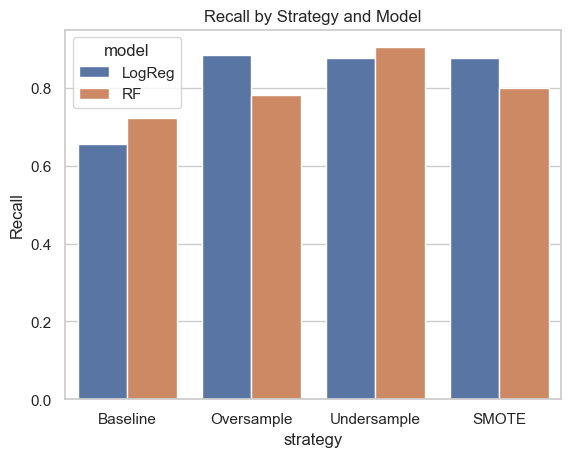

In [5]:
res_df = pd.DataFrame(results).round(3)
res_pivot = res_df.pivot(index="strategy", columns="model", values="f1")
print(res_df)

sns.barplot(data=res_df, x="strategy", y="f1", hue="model")
plt.title("F1-score by Strategy and Model")
plt.ylabel("F1"); plt.show()

sns.barplot(data=res_df, x="strategy", y="recall", hue="model")
plt.title("Recall by Strategy and Model")
plt.ylabel("Recall"); plt.show()

Expected patterns:

Baseline: high accuracy, poor recall for minority class.

Oversample / SMOTE: improved recall and F1, at the cost of some accuracy.

Undersample: smaller training set → can reduce performance variance but may lose signal.

SMOTE: often smoother decision boundaries than naive oversampling.

5) Inspect class balance after resampling

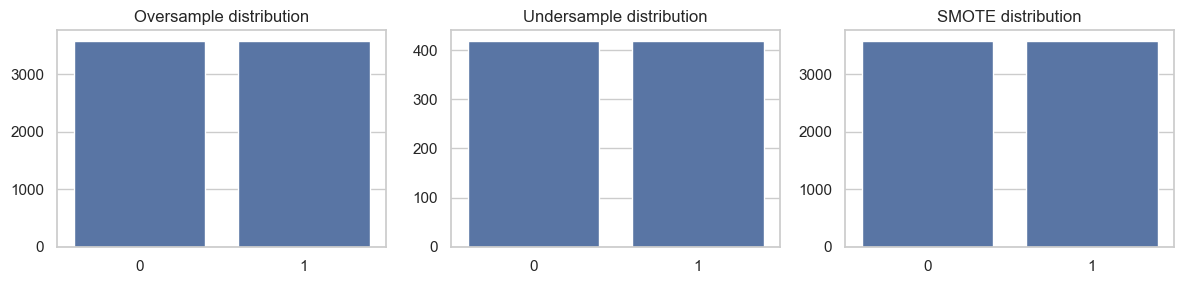

In [6]:
samplers = {"Oversample": RandomOverSampler(), "Undersample": RandomUnderSampler(), "SMOTE": SMOTE()}
fig, axes = plt.subplots(1,3, figsize=(12,3))
for ax, (name, samp) in zip(axes, samplers.items()):
    Xs, ys = samp.fit_resample(Xtr, ytr)
    sns.barplot(x=np.unique(ys), y=np.bincount(ys), ax=ax)
    ax.set_title(name + " distribution")
plt.tight_layout(); plt.show()

6) Confusion matrix example

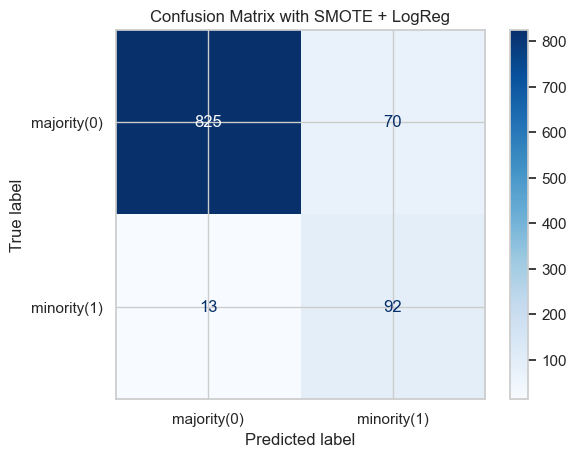

In [7]:
best_pipe = ImbPipeline([('sc', StandardScaler()), ('sampler', SMOTE(random_state=0)),
                         ('clf', LogisticRegression(max_iter=2000))])
best_pipe.fit(Xtr, ytr)
yhat = best_pipe.predict(Xte)
ConfusionMatrixDisplay(confusion_matrix(yte, yhat),
                       display_labels=['majority(0)','minority(1)']).plot(cmap='Blues')
plt.title("Confusion Matrix with SMOTE + LogReg")
plt.show()

Repeat the experiment with more extreme imbalance (e.g., weights=[0.97,0.03]) and observe how strategies behave.

In [8]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, average_precision_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

def run_extreme_imbalance_experiment():
    # 1. Generate Data with Extreme Imbalance (97% vs 3%)
    print("Generating data with weights=[0.97, 0.03]...")
    X, y = make_classification(
        n_samples=20000,
        n_features=20,
        n_informative=2,
        n_redundant=10,
        n_clusters_per_class=1,
        weights=[0.97, 0.03],
        flip_y=0,  # Reduce noise to focus purely on imbalance
        random_state=42
    )

    # Stratified split to maintain the 3% ratio in train/test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )

    print(f"Training set class distribution: {np.bincount(y_train)}")
    print(f"Test set class distribution: {np.bincount(y_test)}\n")

    # 2. Define Strategies
    strategies = {
        "Baseline (No Strategy)": RandomForestClassifier(random_state=42),
        
        "Class Weights (Balanced)": RandomForestClassifier(
            class_weight='balanced', random_state=42
        ),
        
        "SMOTE (Oversampling)": Pipeline([
            ('smote', SMOTE(random_state=42)),
            ('clf', RandomForestClassifier(random_state=42))
        ]),
        
        "Random Undersampling": Pipeline([
            ('under', RandomUnderSampler(random_state=42)),
            ('clf', RandomForestClassifier(random_state=42))
        ])
    }

    # 3. Run Experiment
    results = []
    
    for name, model in strategies.items():
        print(f"--- Running {name} ---")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        # Calculate metrics
        # We focus on the minority class (1) metrics
        report = classification_report(y_test, y_pred, output_dict=True)
        minority_precision = report['1']['precision']
        minority_recall = report['1']['recall']
        minority_f1 = report['1']['f1-score']
        
        # Average Precision (AUPRC) is often better than ROC-AUC for imbalance
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
            auprc = average_precision_score(y_test, y_prob)
        else:
            auprc = 0.0

        cm = confusion_matrix(y_test, y_pred)
        
        results.append({
            "Strategy": name,
            "Precision (Min)": minority_precision,
            "Recall (Min)": minority_recall,
            "F1-Score (Min)": minority_f1,
            "AUPRC": auprc,
            "False Negatives": cm[1][0] # Missed detections
        })

    # 4. Display Results
    results_df = pd.DataFrame(results)
    print("\n=== Experiment Results (Sorted by F1-Score) ===")
    print(results_df.sort_values(by="F1-Score (Min)", ascending=False).to_string(index=False))

if __name__ == "__main__":
    run_extreme_imbalance_experiment()


Generating data with weights=[0.97, 0.03]...
Training set class distribution: [13580   420]
Test set class distribution: [5820  180]

--- Running Baseline (No Strategy) ---
--- Running Class Weights (Balanced) ---
--- Running SMOTE (Oversampling) ---
--- Running Random Undersampling ---

=== Experiment Results (Sorted by F1-Score) ===
                Strategy  Precision (Min)  Recall (Min)  F1-Score (Min)    AUPRC  False Negatives
Class Weights (Balanced)         0.966667      0.966667        0.966667 0.974174                6
  Baseline (No Strategy)         0.971910      0.961111        0.966480 0.981383                7
    SMOTE (Oversampling)         0.925532      0.966667        0.945652 0.975720                6
    Random Undersampling         0.676923      0.977778        0.800000 0.970676                4


Add class_weight='balanced' to Logistic Regression and Random Forest without resampling. Compare with SMOTE.

In [9]:
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, average_precision_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

def run_weighted_vs_smote_experiment():
    # 1. Generate Data with Extreme Imbalance (97% vs 3%)
    X, y = make_classification(
        n_samples=10000,
        n_features=20,
        n_informative=2,
        n_redundant=10,
        weights=[0.97, 0.03], # 3% Minority Class
        flip_y=0,
        random_state=42
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )

    # 2. Define Strategies
    # We compare: Baseline vs Weighted vs SMOTE for both LR and RF
    models = {
        # --- Logistic Regression ---
        "LR (Baseline)": LogisticRegression(solver='liblinear', random_state=42),
        
        "LR (Balanced Weights)": LogisticRegression(
            class_weight='balanced', 
            solver='liblinear', 
            random_state=42
        ),
        
        "LR (SMOTE)": Pipeline([
            ('smote', SMOTE(random_state=42)),
            ('clf', LogisticRegression(solver='liblinear', random_state=42))
        ]),

        # --- Random Forest ---
        "RF (Baseline)": RandomForestClassifier(random_state=42),
        
        "RF (Balanced Weights)": RandomForestClassifier(
            class_weight='balanced', 
            random_state=42
        ),
        
        "RF (SMOTE)": Pipeline([
            ('smote', SMOTE(random_state=42)),
            ('clf', RandomForestClassifier(random_state=42))
        ]),
    }

    # 3. Run Evaluation
    results = []
    print(f"{'Strategy':<30} | {'Recall':<8} | {'Precision':<10} | {'F1':<8} | {'AUPRC':<8}")
    print("-" * 85)

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        # Get probabilities for AUPRC
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
        else:
            y_prob = model.decision_function(X_test)

        # Metrics for the Minority Class (1)
        rec = recall_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred)
        auprc = average_precision_score(y_test, y_prob)

        results.append({
            "Strategy": name,
            "Recall": rec,
            "Precision": prec,
            "F1": f1,
            "AUPRC": auprc
        })
        
        print(f"{name:<30} | {rec:.4f}   | {prec:.4f}     | {f1:.4f}   | {auprc:.4f}")

    # 4. Return DataFrame for analysis
    return pd.DataFrame(results).sort_values(by="F1", ascending=False)

if __name__ == "__main__":
    df_results = run_weighted_vs_smote_experiment()


Strategy                       | Recall   | Precision  | F1       | AUPRC   
-------------------------------------------------------------------------------------
LR (Baseline)                  | 0.3111   | 0.6829     | 0.4275   | 0.5038
LR (Balanced Weights)          | 0.8667   | 0.2254     | 0.3578   | 0.4919
LR (SMOTE)                     | 0.8667   | 0.2356     | 0.3705   | 0.4903
RF (Baseline)                  | 0.4444   | 0.7407     | 0.5556   | 0.6801
RF (Balanced Weights)          | 0.4333   | 0.7800     | 0.5571   | 0.6858
RF (SMOTE)                     | 0.7222   | 0.4514     | 0.5556   | 0.6721


Use cross-validation (5-fold StratifiedKFold) instead of single split and average metrics.

In [ ]:
Use cross-validation (5-fold StratifiedKFold) instead of single split and average metrics.

In [10]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

def run_cv_experiment():
    # 1. Generate Data with Extreme Imbalance (97% vs 3%)
    # We generate a slightly larger dataset to ensure enough minority samples per fold
    X, y = make_classification(
        n_samples=10000,
        n_features=20,
        n_informative=2,
        n_redundant=10,
        weights=[0.97, 0.03], 
        flip_y=0,
        random_state=42
    )

    # 2. Define Strategies
    # Note: SMOTE must be in a Pipeline to ensure it is applied 
    # ONLY to the training folds, preventing data leakage.
    models = {
        # --- Logistic Regression ---
        "LR (Baseline)": LogisticRegression(solver='liblinear', random_state=42),
        
        "LR (Balanced Weights)": LogisticRegression(
            class_weight='balanced', 
            solver='liblinear', 
            random_state=42
        ),
        
        "LR (SMOTE)": Pipeline([
            ('smote', SMOTE(random_state=42)),
            ('clf', LogisticRegression(solver='liblinear', random_state=42))
        ]),

        # --- Random Forest ---
        "RF (Baseline)": RandomForestClassifier(random_state=42),
        
        "RF (Balanced Weights)": RandomForestClassifier(
            class_weight='balanced', 
            random_state=42
        ),
        
        "RF (SMOTE)": Pipeline([
            ('smote', SMOTE(random_state=42)),
            ('clf', RandomForestClassifier(random_state=42))
        ]),
    }

    # 3. Setup Cross-Validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Define metrics we want to track
    # 'average_precision' is the sklearn name for AUPRC
    scoring = {
        'recall': 'recall', 
        'precision': 'precision', 
        'f1': 'f1', 
        'auprc': 'average_precision'
    }

    results = []

    print("Running 5-Fold Cross-Validation...")
    print("-" * 60)

    for name, model in models.items():
        # cross_validate handles the loop, training, and scoring
        cv_results = cross_validate(
            model, X, y, cv=cv, scoring=scoring, n_jobs=-1
        )
        
        # Calculate means and standard deviations
        mean_recall = np.mean(cv_results['test_recall'])
        mean_precision = np.mean(cv_results['test_precision'])
        mean_f1 = np.mean(cv_results['test_f1'])
        mean_auprc = np.mean(cv_results['test_auprc'])
        
        results.append({
            "Strategy": name,
            "Recall (Mean)": mean_recall,
            "Precision (Mean)": mean_precision,
            "F1 (Mean)": mean_f1,
            "AUPRC (Mean)": mean_auprc
        })
        
        print(f"Completed: {name}")

    # 4. Display Results
    df_results = pd.DataFrame(results).sort_values(by="F1 (Mean)", ascending=False)
    
    print("\n=== 5-Fold CV Results (Sorted by F1-Score) ===")
    # Formatting for cleaner output
    print(df_results.to_string(index=False, float_format="%.4f"))

if __name__ == "__main__":
    run_cv_experiment()


Running 5-Fold Cross-Validation...
------------------------------------------------------------
Completed: LR (Baseline)
Completed: LR (Balanced Weights)
Completed: LR (SMOTE)
Completed: RF (Baseline)
Completed: RF (Balanced Weights)
Completed: RF (SMOTE)

=== 5-Fold CV Results (Sorted by F1-Score) ===
             Strategy  Recall (Mean)  Precision (Mean)  F1 (Mean)  AUPRC (Mean)
           RF (SMOTE)         0.7867            0.4507     0.5726        0.6362
        RF (Baseline)         0.4700            0.7346     0.5703        0.6967
RF (Balanced Weights)         0.4433            0.7268     0.5495        0.6924
        LR (Baseline)         0.3567            0.6557     0.4605        0.5153
           LR (SMOTE)         0.8900            0.2203     0.3531        0.4952
LR (Balanced Weights)         0.8933            0.2143     0.3456        0.4946
